In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt 

CREATING TEMPLETES 

In [39]:
templates = {}
for letter in "ABCDEFGHIJKLMNOPQRSTUVWXYZ":
    template = np.ones((64, 64), dtype=np.uint8) * 255
    cv2.putText(
        template,
        letter,
        (8, 50),
        cv2.FONT_HERSHEY_SIMPLEX,
        1.5,
        0,
        2
    )
    coords = cv2.findNonZero(255 - template)
    x, y, w, h = cv2.boundingRect(coords)
    cropped_template = template[y:y+h, x:x+w]
    resized_template = cv2.resize(
        cropped_template,
        (64, 64)
    )
    templates[letter] = resized_template

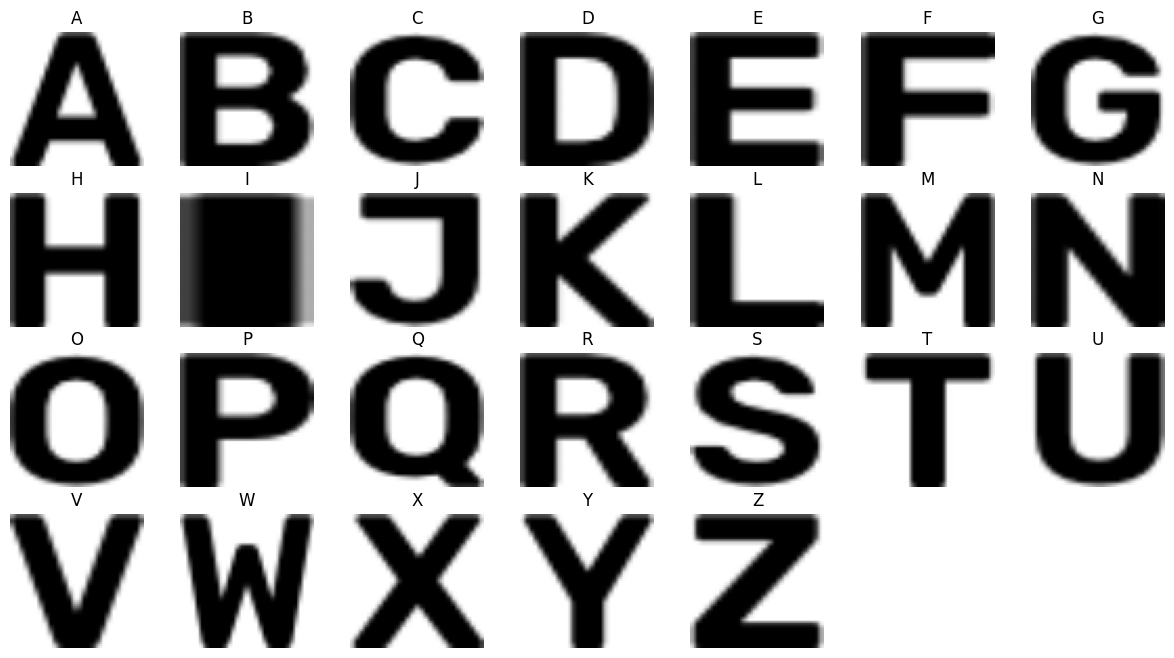

In [42]:
plt.figure(figsize=(15, 8))
for i, letter in enumerate("ABCDEFGHIJKLMNOPQRSTUVWXYZ"):
    plt.subplot(4, 7, i + 1)
    plt.imshow(templates[letter], cmap="gray")
    plt.title(letter)
    plt.axis("off")
plt.show()

In [32]:
templates["A"].shape

(64, 64)

In [4]:
image = cv2.imread("helloworld.jpeg")

In [6]:
print(type(image))

<class 'numpy.ndarray'>


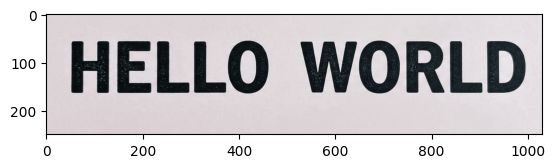

In [7]:
plt.imshow(image)

In [8]:
gray = cv2.cvtColor(image,cv2.COLOR_BGR2GRAY)

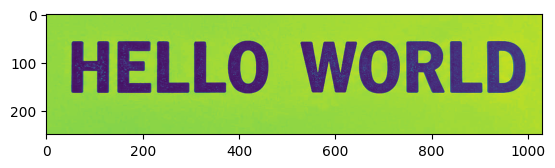

In [9]:
plt.imshow(gray)

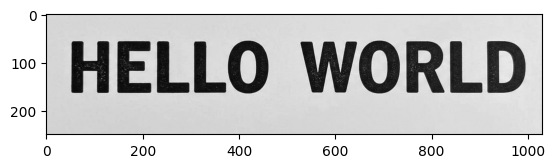

In [10]:
plt.imshow(gray,cmap='gray')

In [11]:
_, threshold = cv2.threshold(
    gray,
    110,
    255,
    cv2.THRESH_BINARY
)

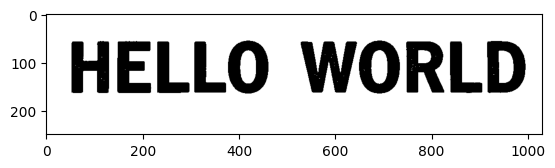

In [14]:
plt.imshow(threshold, cmap='gray')

In [15]:
contours, hierarchy = cv2.findContours(
    threshold,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

In [16]:
print("length of contours ",len(contours))

length of contours  1


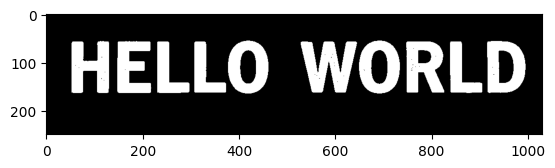

In [17]:
threshold_for_contours = cv2.bitwise_not(threshold)
plt.imshow(threshold_for_contours,cmap='gray')

In [18]:
contours, hierarchy = cv2.findContours(
    threshold_for_contours,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)
print("Contours:", len(contours))

Contours: 10


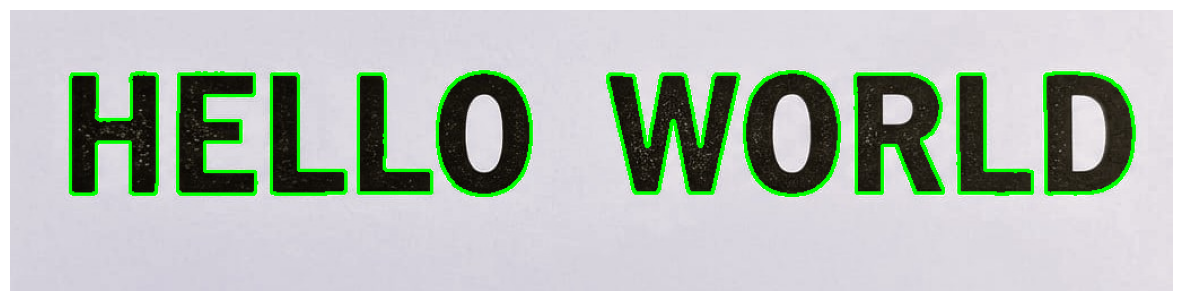

In [19]:
contour_image = image.copy()
cv2.drawContours(
    contour_image,
    contours,
    -1,
    (0, 255, 0),
    2
)
plt.figure(figsize=(15, 6))
plt.imshow(
    cv2.cvtColor(contour_image, cv2.COLOR_BGR2RGB)
)
plt.axis("off");

In [20]:
boxes = []
for contour in contours:
    x, y, w, h = cv2.boundingRect(contour)
    boxes.append((x, y, w, h))

In [21]:
print(boxes)

[(839, 57, 67, 107), (748, 57, 79, 106), (529, 57, 117, 106), (308, 57, 66, 106), (231, 57, 67, 107), (916, 56, 80, 108), (148, 56, 71, 108), (53, 56, 78, 108), (650, 55, 85, 110), (378, 55, 84, 110)]


In [22]:
boxes = sorted(
    boxes,
    key=lambda box: box[0]
)

In [23]:
print(boxes)

[(53, 56, 78, 108), (148, 56, 71, 108), (231, 57, 67, 107), (308, 57, 66, 106), (378, 55, 84, 110), (529, 57, 117, 106), (650, 55, 85, 110), (748, 57, 79, 106), (839, 57, 67, 107), (916, 56, 80, 108)]


In [25]:
boxed_image = image.copy()
for i, (x, y, w, h) in enumerate(boxes):
    cv2.rectangle(
        boxed_image,
        (x, y),
        (x + w, y + h),
        (0, 255, 0),
        2
    )

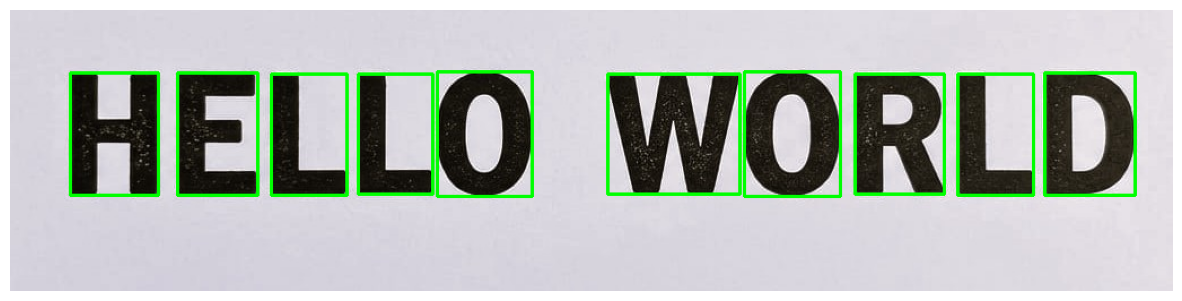

In [26]:
plt.figure(figsize=(15, 6))
plt.imshow(cv2.cvtColor(boxed_image, cv2.COLOR_BGR2RGB))
plt.axis("off");

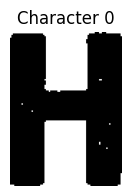

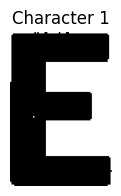

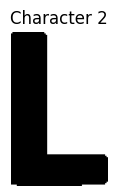

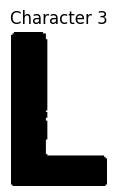

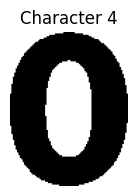

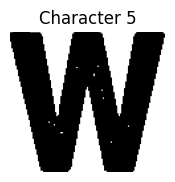

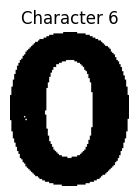

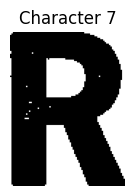

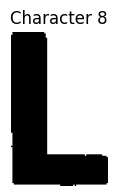

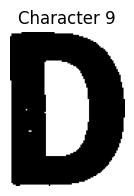

In [27]:
characters = []
for i, (x, y, w, h) in enumerate(boxes):
    character = threshold[y:y+h, x:x+w]
    characters.append(character)
    plt.figure(figsize=(2, 2))
    plt.imshow(character, cmap="gray")
    plt.title(f"Character {i}")
    plt.axis("off")
    plt.show()

In [33]:
character.shape

(108, 80)

In [34]:
resized_character = cv2.resize(character, (64, 64))

In [35]:
resized_character.shape

(64, 64)

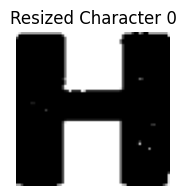

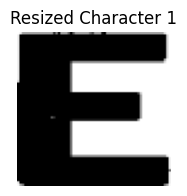

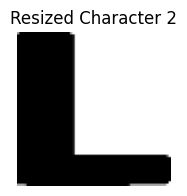

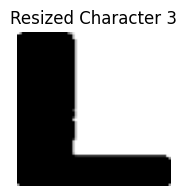

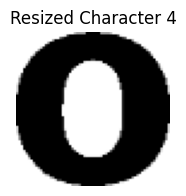

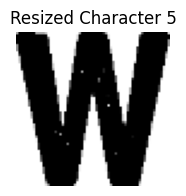

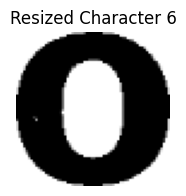

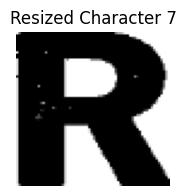

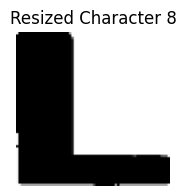

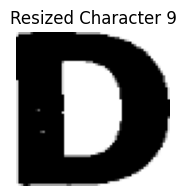

In [36]:
resized_characters = []
for i, character in enumerate(characters):
    resized_character = cv2.resize(character,(64, 64))
    resized_characters.append(resized_character)
    plt.figure(figsize=(2, 2))
    plt.imshow(resized_character, cmap="gray")
    plt.title(f"Resized Character {i}")
    plt.axis("off")
    plt.show()

In [40]:
recognized_text = ""
for input_character in resized_characters:
    min_diff = float("inf")
    predicted_character = ""
    for letter, template in templates.items():
        difference = np.abs(
            input_character.astype(np.int16)-template.astype(np.int16)
        )
        score = np.sum(difference)
        if score < min_diff:
            min_diff = score
            predicted_character = letter
    recognized_text += predicted_character
print("Recognized text:", recognized_text)

Recognized text: HELLOWORLD


# Level 1 — Character Segmentation and Template Matching

## Objective

To recognize English characters from an image using a basic
pixel-based template matching approach.

## Pipeline

Image
→ Grayscale
→ Thresholding
→ Contour Detection
→ Bounding Boxes
→ Character Cropping
→ Resize to 64×64
→ Template Generation
→ Pixel-by-Pixel Comparison
→ Minimum Difference
→ Character Prediction

## Experiment

A test image containing:

HELLO WORLD

was generated using the same font and character settings as the
templates.

## Result

Recognized output:

HELLOWORLD

All characters were recognized correctly under the controlled
same-font condition.

## Why did this work?

The test characters and templates had the same:

- Font
- Font size
- Stroke thickness
- Character structure
- Image preprocessing

Therefore, their pixel patterns were highly similar.

## Limitations

1. The method is highly dependent on the character style/font.
2. It performs poorly when the handwriting differs significantly
   from the templates.
3. Pixel-level comparison is sensitive to position, size and
   stroke thickness.
4. A separate template is required for each character.
5. Spaces are not currently recognized because spaces do not form
   contours.
6. The method does not generalize well to arbitrary handwriting.

## Conclusion

Basic pixel-based template matching can recognize characters
effectively under controlled and consistent conditions.

However, it is not sufficiently robust for general handwritten
text recognition. This motivates the development of more
advanced recognition methods.